# Analyzing the Impact of Sleep Habits on Academic Performance
<!-- **Author:** [Your Name] | **Course/Project:** [Your Class/Assignment Name] -->

### Project Objective
This project investigates the relationship between college students' sleep habits and their academic performance (Term GPA). Using a dataset of 634 students tracked across multiple semesters, we aim to build a regression model that identifies which behavioral factors—such as sleep duration, consistency, and daytime napping—are the strongest predictors of academic success when controlling for baseline performance.

### Table of Contents
1. **Environment Setup & Data Loading:** Importing libraries and reading the dataset.
2. **Data Cleaning & Imputation:** Handling missing values.
3. **Exploratory Data Analysis (EDA):** Visualizing distributions and feature correlations.
4. **Feature Selection:** Identifying mathematical signals and removing target leakage.
5. **Model Preparation:** Splitting and scaling the dataset for machine learning.
6. **Model Training & Comparison:** Evaluating linear, regularized, and non-linear models.
7. **Hyperparameter Tuning:** Optimizing the highest-performing model.
8. **Final Conclusion & Feature Importance:** Interpreting the results.

---
## 1. Environment Setup & Data Loading
In this section, we import the necessary data science libraries for manipulation, visualization, and machine learning, and load our dataset into a Pandas DataFrame.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import sklearn
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Data Analysis and Exploration
import matplotlib.pyplot as plt
import seaborn as sns

def regression_report(y_true, y_pred):
    """Generates a text report of core regression metrics."""
    mae = mean_absolute_error(y_true, y_pred)
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_true, y_pred)
    
    # Calculate Adjusted R-squared if you track number of features (p)
    # n = len(y_true)
    # adj_r2 = 1 - ((1 - r2) * (n - 1) / (n - p - 1))
    
    print("=== Regression Performance Report ===")
    print(f"Mean Absolute Error (MAE)     : {mae:.4f}")
    print(f"Mean Squared Error (MSE)       : {mse:.4f}")
    print(f"Root Mean Squared Error (RMSE) : {rmse:.4f}")
    print(f"R-squared (R²) Score           : {r2:.4f}")
    print("=====================================")

In [3]:
import kagglehub
from kagglehub import KaggleDatasetAdapter

file_path = "college_sleep_and_gpa.csv"

df = kagglehub.dataset_load(
    KaggleDatasetAdapter.PANDAS,
    "kylefengkfeng209/sleep-vs-gpa-in-college",
    file_path,
)

df.head()

,student_id,study,university,semester,cohort_code,gender,first_generation,underrepresented,avg_sleep_minutes,avg_sleep_hours,...,bedtime_variability,nights_tracked_fraction,prior_gpa,term_gpa,gpa_change,term_units,term_load_z,under_6h_sleep,sleep_bracket,sleep_midpoint_clock
0,293,1,Carnegie Mellon University,Spring 2018,lac2,Female,0.0,0.0,370.0,6.17,...,0.0500,0.931,4.00,3.76,-0.24,49.0,0.112,0,6-6.5h,07:20
1,294,1,Carnegie Mellon University,Spring 2018,lac2,Female,0.0,0.0,406.8,6.78,...,0.0476,0.862,4.00,3.55,-0.45,49.0,0.112,0,6.5-7h,05:00
2,297,1,Carnegie Mellon University,Spring 2018,lac2,Female,0.0,1.0,253.8,4.23,...,0.1639,0.586,3.00,3.59,0.59,46.0,-0.604,1,<5.5h,05:38
3,303,1,Carnegie Mellon University,Spring 2018,lac2,Female,0.0,0.0,411.9,6.86,...,0.7854,0.931,3.80,3.46,-0.34,39.0,-2.275,0,6.5-7h,07:52
4,304,1,Carnegie Mellon University,Spring 2018,lac2,Female,0.0,1.0,408.1,6.80,...,0.1538,0.931,3.17,3.50,0.33,39.0,-2.275,0,6.5-7h,04:54


---
## 2. Data Cleaning & Imputation
Real-world datasets are rarely perfect. Before visualizing or training models, we must handle missing values to ensure mathematical operations do not fail. 

**Strategy:**
* **Numerical Features:** Imputed using the mean (average).
* **Categorical/Binary Features:** Imputed using the mode (most frequent occurrence).

In [4]:
# 1. Display missing values before cleaning
print("--- Missing values before cleaning ---")
print(df.isnull().sum()[df.isnull().sum() > 0]) # Only show columns with missing data

# 2. Impute numerical columns with the MEAN
numeric_missing = ['term_units', 'term_load_z']
for col in numeric_missing:
    df[col] = df[col].fillna(df[col].mean())

# 3. Impute categorical/binary columns with the MODE (most frequent value)
categorical_missing = ['gender', 'first_generation', 'underrepresented']
for col in categorical_missing:
    df[col] = df[col].fillna(df[col].mode()[0])

# 4. Verify that all missing values have been handled
print("\n--- Missing values after cleaning ---")
print(df.isnull().sum())

--- Missing values before cleaning ---
gender                3
first_generation      4
underrepresented      1
term_units          147
term_load_z         147
dtype: int64

--- Missing values after cleaning ---
student_id                 0
study                      0
university                 0
semester                   0
cohort_code                0
gender                     0
first_generation           0
underrepresented           0
avg_sleep_minutes          0
avg_sleep_hours            0
daytime_sleep_minutes      0
sleep_midpoint_minutes     0
bedtime_variability        0
nights_tracked_fraction    0
prior_gpa                  0
term_gpa                   0
gpa_change                 0
term_units                 0
term_load_z                0
under_6h_sleep             0
sleep_bracket              0
sleep_midpoint_clock       0
dtype: int64


---
## 3. Exploratory Data Analysis (EDA)
To understand the underlying patterns in our data, we visualize the distributions of our target variable (`term_gpa`) and our primary feature of interest (`avg_sleep_hours`). We also generate a correlation heatmap to mathematically quantify the linear relationships between all numerical variables.

In [5]:
sns.set_theme(style="whitegrid")

In [6]:
print("=== Summary Statistics for Key Variables ===")
key_cols = ['term_gpa', 'prior_gpa', 'avg_sleep_hours', 'bedtime_variability', 'term_units']
display(df[key_cols].describe())

=== Summary Statistics for Key Variables ===


,term_gpa,prior_gpa,avg_sleep_hours,bedtime_variability,term_units
count,634.000000,634.000000,634.000000,634.000000,634.000000
mean,3.449587,3.465584,6.622098,0.451687,29.392197
std,0.500463,0.437578,0.847741,1.393631,15.459067
min,0.350000,1.210000,3.250000,0.004500,5.000000
25%,3.233000,3.232250,6.112500,0.074700,15.000000
50%,3.556000,3.558000,6.675000,0.135000,29.392197
75%,3.810000,3.789500,7.170000,0.291700,45.000000
max,4.000000,4.000000,9.790000,20.849200,73.000000


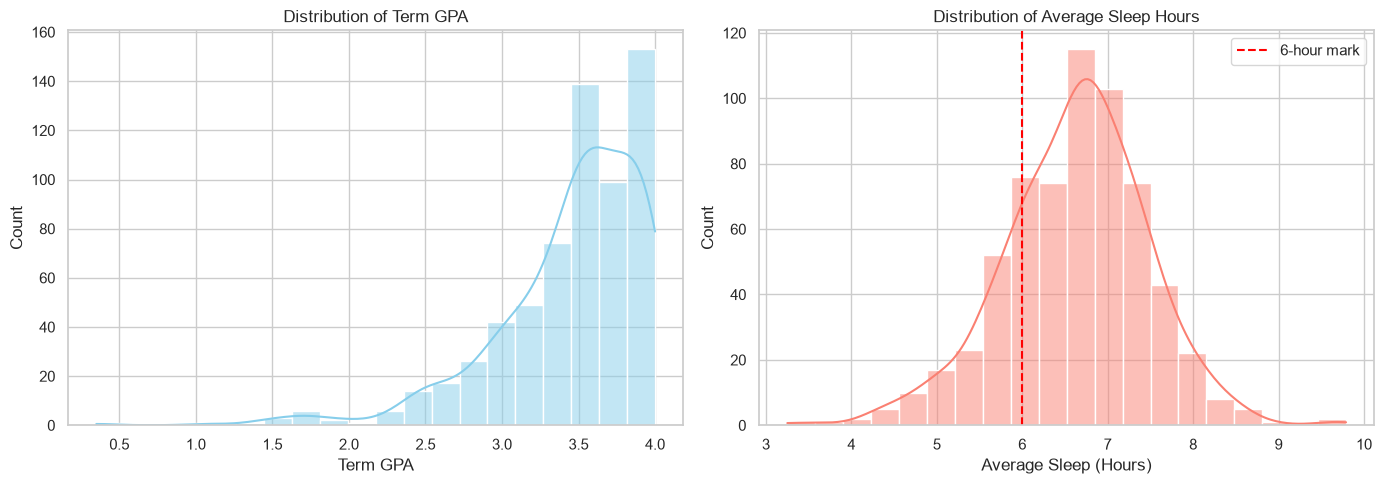

In [7]:
plt.figure(figsize=(14, 5))

# Plot 1: Distribution of Term GPA
plt.subplot(1, 2, 1)
sns.histplot(df['term_gpa'], bins=20, kde=True, color='skyblue')
plt.title('Distribution of Term GPA')
plt.xlabel('Term GPA')
plt.ylabel('Count')

# Plot 2: Distribution of Average Sleep Hours
plt.subplot(1, 2, 2)
sns.histplot(df['avg_sleep_hours'], bins=20, kde=True, color='salmon')
plt.axvline(6, color='red', linestyle='--', label='6-hour mark')
plt.title('Distribution of Average Sleep Hours')
plt.xlabel('Average Sleep (Hours)')
plt.ylabel('Count')
plt.legend()

plt.tight_layout()
plt.show()

C:\Users\HP\AppData\Local\Temp\ipykernel_11308\3911516668.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='sleep_bracket', y='term_gpa', order=bracket_order, palette='Set2')


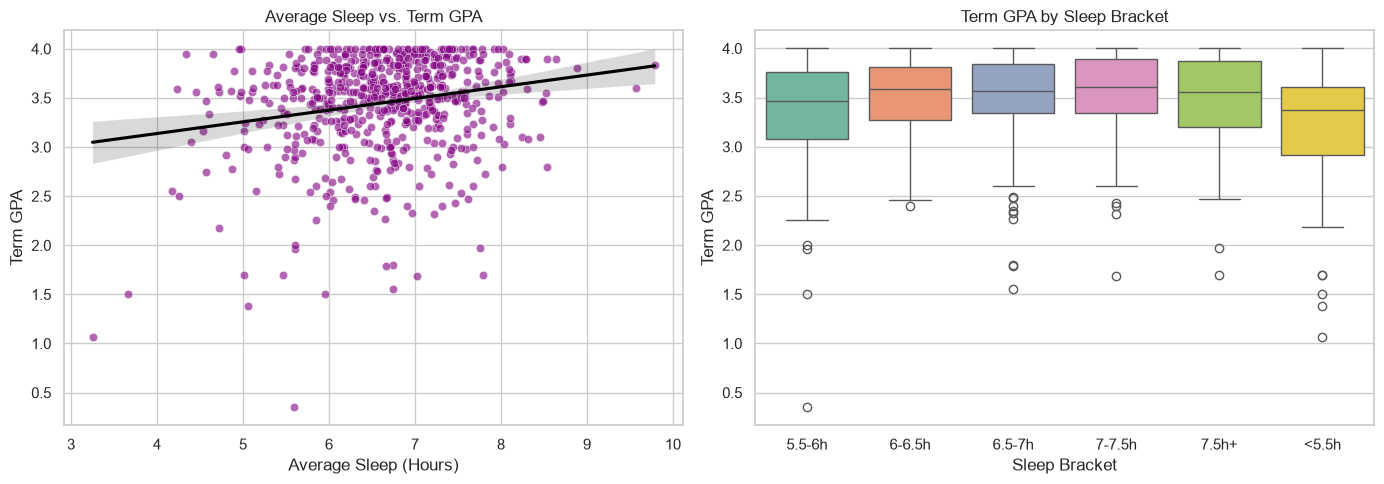

In [8]:
plt.figure(figsize=(14, 5))

# Plot 1: Sleep Hours vs Term GPA
plt.subplot(1, 2, 1)
sns.scatterplot(data=df, x='avg_sleep_hours', y='term_gpa', alpha=0.6, color='purple')
# Adding a trendline
sns.regplot(data=df, x='avg_sleep_hours', y='term_gpa', scatter=False, color='black')
plt.title('Average Sleep vs. Term GPA')
plt.xlabel('Average Sleep (Hours)')
plt.ylabel('Term GPA')

# Plot 2: Boxplot of Term GPA by Sleep Bracket
plt.subplot(1, 2, 2)
# Sorting the brackets so they appear in a logical order
bracket_order = sorted(df['sleep_bracket'].unique()) 
sns.boxplot(data=df, x='sleep_bracket', y='term_gpa', order=bracket_order, palette='Set2')
plt.title('Term GPA by Sleep Bracket')
plt.xlabel('Sleep Bracket')
plt.ylabel('Term GPA')

plt.tight_layout()
plt.show()

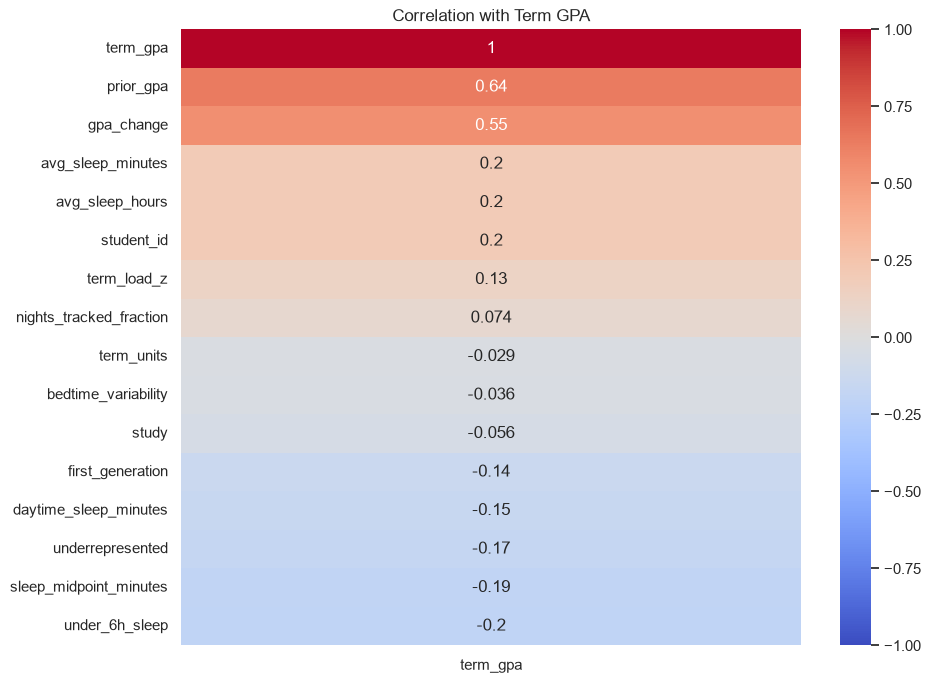

In [9]:
plt.figure(figsize=(10, 8))

# Select only numerical columns for the correlation matrix
numeric_df = df.select_dtypes(include=['float64', 'int64'])
corr_matrix = numeric_df.corr()

# Plot the heatmap, focusing on the relationships with term_gpa
sns.heatmap(corr_matrix[['term_gpa']].sort_values(by='term_gpa', ascending=False), 
            annot=True, cmap='coolwarm', vmin=-1, vmax=1)

plt.title('Correlation with Term GPA')
plt.show()

---
## 4. Feature Selection
Based on the correlation analysis, we must selectively choose which features to feed into our machine learning models. 

**Selected Features (The Signals):**
* **`prior_gpa`:** The strongest baseline predictor of future academic performance.
* **Sleep Metrics:** `avg_sleep_hours`, `under_6h_sleep`, `sleep_midpoint_minutes`, and `daytime_sleep_minutes`.
* **Demographics & Workload:** `underrepresented`, `first_generation`, and `term_load_z`.

**Dropped Features (The Noise & Traps):**
* **`gpa_change`:** Dropped to prevent target leakage (it is derived directly from the target variable).
* **`student_id`:** Dropped as it is a random identifier with spurious correlation.
* **`avg_sleep_minutes` & `term_units`:** Dropped to prevent multicollinearity (they are redundant to `avg_sleep_hours` and `term_load_z`).

---
## 5. Model Preparation
Before training, we must prepare our data to ensure our models learn effectively and can be evaluated fairly.

1. **Train/Validation Split:** We reserve 20% of the dataset as a hidden validation set to test how well our models generalize to unseen data.
2. **Feature Scaling:** Because our features are measured in vastly different units (e.g., GPA vs. minutes of sleep), we apply a `StandardScaler`. This centers all features around a mean of 0 with a standard deviation of 1, preventing distance-based models (like SVR or Neural Networks) from being biased by large numbers.

In [57]:
# 1. Define Features (X) and Target (y)
# We explicitly select only the strong predictors and safe demographics
features = [
    'prior_gpa', 
    'avg_sleep_hours', 
    'under_6h_sleep', 
    'sleep_midpoint_minutes', 
    'daytime_sleep_minutes', 
    'underrepresented', 
    'first_generation', 
    'term_load_z'
]

X = df[features]
y = df['term_gpa']

# 2. Split the Data
# 80% of the data goes to training, 20% to validation.
# random_state=42 ensures you get the exact same random split every time you run the cell.
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

# 3. Scale the Features
# This puts all variables on the same scale (mean of 0, standard deviation of 1)
scaler = StandardScaler()

# We learn the scaling rules ONLY from the training data, then apply it to both sets.
# This prevents "data leakage" from the validation set into the training process.
# X_train_scaled = scaler.fit_transform(X_train)
# X_val_scaled = scaler.transform(X_val)

# print(f"Training features shape: {X_train_scaled.shape}")
# print(f"Validation features shape: {X_val_scaled.shape}")

In [58]:
display(np.unique(df['first_generation']))
print(np.unique(df['underrepresented']))

array([0., 1., 2.])

[0. 1.]


---
## 6. Model Training & Comparison
We will train and evaluate a diverse suite of regression algorithms to determine which architecture best captures the relationship between sleep and GPA.

* **Linear Models:** Linear Regression, Ridge ($L_2$), Lasso ($L_1$), and ElasticNet.
* **Non-Linear Models:** Support Vector Regressor (RBF Kernel) and a Multi-Layer Perceptron (Artificial Neural Network).

The models are evaluated primarily on their **R-squared (R²)** score and **Root Mean Squared Error (RMSE)**.

In [60]:
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.svm import SVR
from sklearn.neural_network import MLPRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# 1. Initialize all models in a dictionary
models = {
    "Linear Regression": LinearRegression(),
    "Ridge Regression": Ridge(alpha=0.05),
    "Lasso Regression": Lasso(alpha=0.05),
    "ElasticNet": ElasticNet(alpha=0.05, l1_ratio=0.5),
    "Support Vector Regressor (SVR)": SVR(kernel='linear', C=1.0),
    "Artificial Neural Network (MLP)": MLPRegressor(hidden_layer_sizes=(8, 8, ), max_iter=1000, random_state=42)
}

# 2. Train and evaluate each model
results = []

for name, model in models.items():
    # Fit on training data
    model.fit(X_train, y_train)
    
    # Predict on validation data
    y_pred = model.predict(X_val)
    
    # Print the detailed report using your custom function
    print(f"\n>>> {name} <<<")
    regression_report(y_val, y_pred)
    
    # Collect metrics for comparison table
    mae = mean_absolute_error(y_val, y_pred)
    rmse = np.sqrt(mean_squared_error(y_val, y_pred))
    r2 = r2_score(y_val, y_pred)
    
    results.append({
        "Model": name,
        "MAE": round(mae, 4),
        "RMSE": round(rmse, 4),
        "R² Score": round(r2, 4)
    })

# 3. Create a clean comparison summary DataFrame
comparison_df = pd.DataFrame(results).sort_values(by="R² Score", ascending=False).reset_index(drop=True)
print("\n=== Model Comparison Summary ===")
display(comparison_df)


>>> Linear Regression <<<
=== Regression Performance Report ===
Mean Absolute Error (MAE)     : 0.2820
Mean Squared Error (MSE)       : 0.1493
Root Mean Squared Error (RMSE) : 0.3865
R-squared (R²) Score           : 0.3470

>>> Ridge Regression <<<
=== Regression Performance Report ===
Mean Absolute Error (MAE)     : 0.2820
Mean Squared Error (MSE)       : 0.1493
Root Mean Squared Error (RMSE) : 0.3865
R-squared (R²) Score           : 0.3470

>>> Lasso Regression <<<
=== Regression Performance Report ===
Mean Absolute Error (MAE)     : 0.2867
Mean Squared Error (MSE)       : 0.1535
Root Mean Squared Error (RMSE) : 0.3918
R-squared (R²) Score           : 0.3287

>>> ElasticNet <<<
=== Regression Performance Report ===
Mean Absolute Error (MAE)     : 0.2830
Mean Squared Error (MSE)       : 0.1490
Root Mean Squared Error (RMSE) : 0.3860
R-squared (R²) Score           : 0.3485

>>> Support Vector Regressor (SVR) <<<
=== Regression Performance Report ===
Mean Absolute Error (MAE)     : 0.2

,Model,MAE,RMSE,R² Score
0,Support Vector Regressor (SVR),0.2543,0.3684,0.4066
1,ElasticNet,0.2830,0.3860,0.3485
2,Ridge Regression,0.2820,0.3865,0.3470
3,Linear Regression,0.2820,0.3865,0.3470
4,Lasso Regression,0.2867,0.3918,0.3287
5,Artificial Neural Network (MLP),0.3548,0.5035,-0.1083


---
## 7. Hyperparameter Tuning
The initial baseline testing indicated that **Lasso Regression** achieved the highest performance. Lasso is particularly effective here because its $L_1$ regularization penalty performs automatic feature selection by shrinking the coefficients of unhelpful features to exactly zero. 

We will use `GridSearchCV` with 5-fold cross-validation to find the mathematically optimal `alpha` (regularization strength) for the Lasso model.

In [54]:
predict = models["Support Vector Regressor (SVR)"].predict(X_val)

display(predict)
display(y_val)

C:\Users\HP\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\utils\validation.py:2820: UserWarning: X has feature names, but SVR was fitted without feature names
  warnings.warn(


array([-0.68085749, -0.65741912, -1.2263992 , -0.56066855, -2.83748922,
       -2.12196875, -1.7224109 , -2.69232315, -2.60945766, -5.63385442,
       -1.90146955, -1.94429708, -1.65871225,  0.52789867, -0.86185997,
       -1.45524553, -1.45803864, -1.39648208, -0.61790911, -2.83112976,
       -4.05268949, -1.4591947 , -2.56883426, -1.67292942, -4.81648307,
       -2.70746046, -1.39548081, -0.33430323, -0.61667014, -2.76879632,
       -1.32885648,  0.28498229, -1.2731475 , -1.51113813, -1.51509455,
       -0.37417613, -1.89703169,  0.15050903, -2.53293581, -1.6489618 ,
       -1.23838772, -1.85743782, -1.89450965, -4.10176884, -1.97386387,
       -3.38079549,  0.03341625, -0.76674048, -0.56183483, -5.10381013,
       -0.86633531, -2.46919987, -4.02854128, -1.06017175, -2.1864827 ,
       -1.26576042, -3.60814672, -0.7670688 , -2.25338326, -4.36906175,
       -1.10014868, -2.34612879, -3.38184705, -0.66747157, -1.62183516,
       -6.19814679, -0.36975556, -1.0097302 , -3.01517221, -2.20

396    3.556
248    3.300
215    3.950
353    3.710
548    3.380
       ...  
556    3.770
265    3.950
473    3.944
464    3.556
340    3.620
Name: term_gpa, Length: 127, dtype: float64

--- 1. Hyperparameter Tuning (Lasso) ---
Optimal Alpha found: 0.01
Cross-Validation R² Score: 0.3860

--- 2. Final Evaluation on Validation Set ---
Final Validation R²: 0.3602
Final Validation RMSE: 0.3825

--- 3. Feature Importance (Coefficients) ---
under_6h_sleep           -0.028484
underrepresented         -0.022733
daytime_sleep_minutes    -0.012930
first_generation         -0.012667
sleep_midpoint_minutes   -0.003842
term_load_z               0.026606
avg_sleep_hours           0.035123
prior_gpa                 0.294384
dtype: float64


C:\Users\ROG\AppData\Local\Temp\ipykernel_31188\725638244.py:39: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=coefficients.values, y=coefficients.index, palette="viridis")


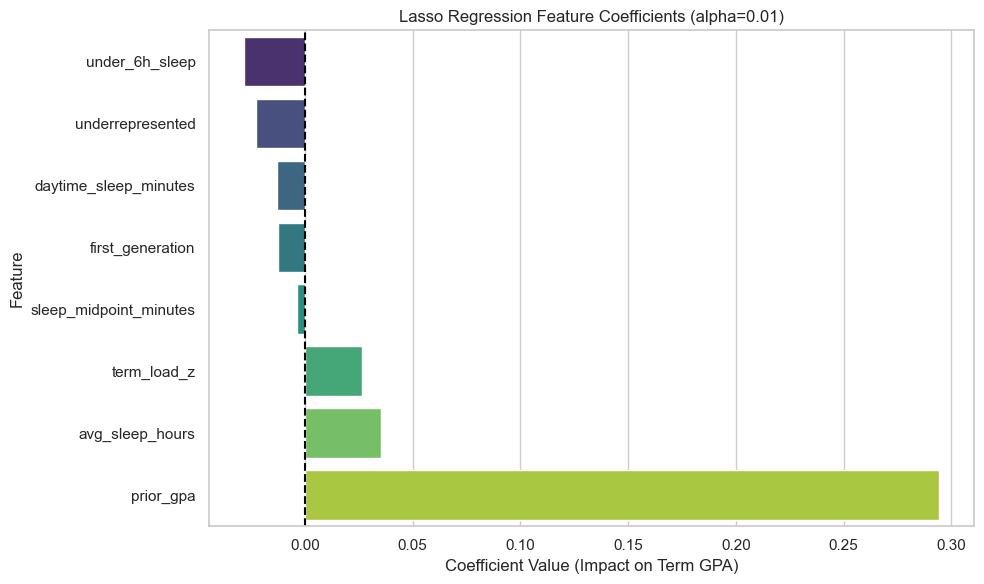

In [64]:
print("--- 1. Hyperparameter Tuning (Lasso) ---")
# Set up a grid of alpha values to test. 
# Smaller alpha = closer to standard Linear Regression. Larger alpha = heavier penalty/more features dropped.
param_grid = {'alpha': [0.0001, 0.001, 0.005, 0.01, 0.05, 0.1, 0.5, 1.0]}

# Initialize GridSearchCV with 5-fold cross-validation
lasso_grid = GridSearchCV(
    Lasso(random_state=42), 
    param_grid, 
    cv=5, 
    scoring='r2' # We want to optimize for the best R-squared score
)

# Fit the grid search on the training data
lasso_grid.fit(X_train_scaled, y_train)

# Extract the best model
best_lasso = lasso_grid.best_estimator_
best_alpha = lasso_grid.best_params_['alpha']

print(f"Optimal Alpha found: {best_alpha}")
print(f"Cross-Validation R² Score: {lasso_grid.best_score_:.4f}")

print("\n--- 2. Final Evaluation on Validation Set ---")
y_pred_best = best_lasso.predict(X_val_scaled)
print(f"Final Validation R²: {r2_score(y_val, y_pred_best):.4f}")
print(f"Final Validation RMSE: {np.sqrt(mean_squared_error(y_val, y_pred_best)):.4f}")


print("\n--- 3. Feature Importance (Coefficients) ---")
# Extract the coefficients from the best model
coefficients = pd.Series(best_lasso.coef_, index=features).sort_values()

# Display the exact weights
print(coefficients)

# Plot the feature importances
plt.figure(figsize=(10, 6))
sns.barplot(x=coefficients.values, y=coefficients.index, palette="viridis")
plt.title(f"Lasso Regression Feature Coefficients (alpha={best_alpha})")
plt.xlabel("Coefficient Value (Impact on Term GPA)")
plt.ylabel("Feature")
plt.axvline(x=0, color='black', linestyle='--')
plt.tight_layout()
plt.show()

---
## 8. Final Conclusion & Feature Importance

### Model Optimization Results
The hyperparameter tuning process confirmed that a mild regularization penalty (`alpha = 0.01`) is optimal for this dataset. The final Lasso model achieved a Cross-Validation R² of **0.3860** and a Validation R² of **0.3602**. 

### Coefficient Analysis
Because all features were standardized prior to training, the absolute magnitude of each coefficient directly reflects its predictive power.

**Key Findings:**
1. **Historical Performance is Paramount:** `prior_gpa` (0.294) is overwhelmingly the strongest predictor. A student's established academic baseline heavily anchors their future grades.
2. **The Sleep Penalty:** The most significant negative behavioral factor is `under_6h_sleep` (-0.028). Consistently failing to achieve 6 hours of sleep acts as a measurable penalty to academic performance. Furthermore, poor sleep scheduling, such as being a extreme night owl (`sleep_midpoint_minutes`) or requiring frequent naps (`daytime_sleep_minutes`), slightly depresses final grades.
3. **The Sleep Benefit:** Conversely, a higher overall `avg_sleep_hours` (0.035) serves as the strongest positive lifestyle factor, providing a distinct academic advantage.

**Final Takeaway:** 
The data validates the core research hypothesis: while baseline intelligence and study habits (represented by prior GPA) set the foundation, healthy sleep habits—specifically avoiding severe sleep deprivation and maintaining consistent nightly rest—have a tangible, positive impact on a student's final GPA.